1:  What is Deep Learning? Briefly describe how it evolved and how it differs
from traditional machine learning.

Deep Learning is a subfield of Machine Learning.
It uses multi-layer artificial neural networks to learn patterns from data.
It automatically extracts features without manual intervention.
Key Points:
Inspired by the structure of the human brain.
Works best on large and complex datasets.
Used in image recognition, NLP, speech recognition, etc.

Evolution:
1943: McCulloch & Pitts neuron model (basic idea of neural networks)
1958: Perceptron introduced by Frank Rosenblatt
1986: Backpropagation algorithm popularized neural network training
2006: Geoffrey Hinton introduced “Deep Learning” concept
2010 onwards: GPUs + Big Data → rapid growth of deep learning
Present: CNN, RNN, Transformers dominate AI applications

Difference from Machine Learning:
ML requires manual feature engineering, DL learns features automatically.
ML works well on small datasets, DL requires large datasets.
ML uses simpler models (SVM, Decision Tree), DL uses neural networks.
ML performance depends on feature quality, DL improves with more data.
DL is computationally expensive (needs GPU/TPU).

Question 2:  Explain the basic architecture and functioning of a Perceptron. What are its
limitations?

Definition:
A Perceptron is the simplest type of artificial neural network.
It is used for binary classification problems.
Architecture:
Input layer (features: x1, x2, … xn)
Weights (w1, w2, … wn)
Bias term (b)
Summation function:
z = (w1x1 + w2x2 + ... + wnxn) + b
Activation function (Step function)
Working:
Step 1: Input features are multiplied by weights
Step 2: Add bias term
Step 3: Compute weighted sum
Step 4: Apply activation function
Step 5: Output is 0 or 1

Learning Rule:
If prediction is wrong:
Update weights using error correction rule
Adjust bias accordingly

Limitations:
Can only solve linearly separable problems
Cannot solve XOR problem
No hidden layers → limited learning capability
Poor performance on complex real-world data
Not suitable for deep learning tasks

Question 3:: Describe the purpose of activation function in neural networks. Compare
Sigmoid, ReLU, and Tanh functions.

Introduce non-linearity in neural networks
Help model learn complex relationships
Decide whether a neuron should activate or not
Sigmoid Function:
Formula: 1 / (1 + e^(-x))
Output range: 0 to 1
Used in binary classification output layer
Smooth curve (S-shaped)

Problems:
Vanishing gradient issue
Slow convergence
Not zero-centered
ReLU (Rectified Linear Unit):
Formula: max(0, x)
Output range: 0 to infinity
Most widely used activation function

Advantages:
Fast computation
Reduces vanishing gradient problem
Works well in deep networks

Problems:
Dying ReLU problem (neurons can become inactive)
Tanh Function:

Formula: (e^x - e^-x) / (e^x + e^-x)
Output range: -1 to +1
Zero-centered output

Advantages:
Better than sigmoid in hidden layers

Problems:
Still suffers from vanishing gradient
Comparison:
Sigmoid → probability output
ReLU → best for hidden layers
Tanh → centered activation but slower

Question 4:  What is the difference between Loss function and Cost function in neural
networks? Provide examples.

Loss Function:
Measures error for single training example
Shows how wrong a prediction is for one data point
Cost Function:
Average of loss function over entire dataset
Represents overall model performance

Examples:
Regression:
Mean Squared Error (MSE)
Classification:
Binary Cross Entropy
Categorical Cross Entropy

Key Differences:
Loss function → individual sample error
Cost function → total dataset error
Loss is used during training step-by-step
Cost is minimized during optimization process
Importance:
Helps model learn by reducing error
Guides optimizer direction
Essential for training neural networks


Question 5:  What is the role of optimizers in neural networks? Compare Gradient
Descent, Adam, and RMSprop.

Optimizers are algorithms used to update weights and reduce loss.
They help improve model accuracy during training.
Gradient Descent:
Basic optimization algorithm
Updates weights in direction of negative gradient
Can be:
Batch Gradient Descent
Stochastic Gradient Descent

Limitations:
Slow convergence
Can get stuck in local minima
RMSprop:
Adaptive learning rate method
Divides learning rate by moving average of squared gradients
Works well for RNNs

Advantages:
Faster convergence than SGD
Handles non-stationary data
Adam Optimizer:
Combination of Momentum + RMSprop
Uses adaptive learning rates for each parameter

Advantages:
Fast and efficient
Works well in most deep learning models
Less tuning required
Comparison:
Gradient Descent → simple but slow
RMSprop → good for sequential data
Adam → best overall optimizer for deep learning

In [1]:
#6
import numpy as np

# Input data for AND gate
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([0,0,0,1])

weights = np.random.rand(2)
bias = 0
lr = 0.1

def step(z):
    return 1 if z >= 0 else 0

# Training
for epoch in range(10):
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        pred = step(z)
        error = y[i] - pred
        weights += lr * error * X[i]
        bias += lr * error

print("Final Weights:", weights)
print("Bias:", bias)

# Testing
for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    print(X[i], ":", step(z))

Final Weights: [0.15987593 0.06514363]
Bias: -0.2
[0 0] : 0
[0 1] : 0
[1 0] : 0
[1 1] : 1


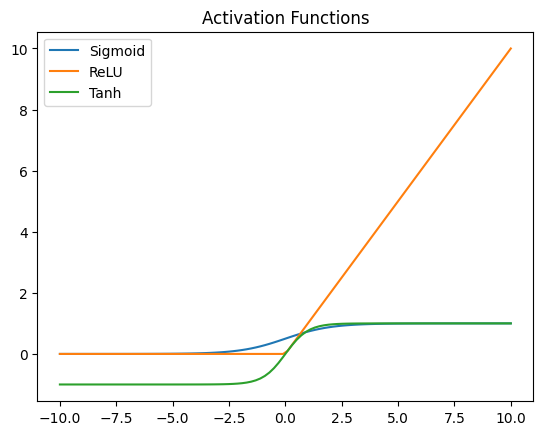

In [2]:
#7
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

sigmoid = 1/(1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.figure()

plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, relu, label="ReLU")
plt.plot(x, tanh, label="Tanh")

plt.legend()
plt.title("Activation Functions")
plt.show()

In [3]:
#8
import tensorflow as tf
from tensorflow import keras

mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9262 - loss: 0.2604
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9665 - loss: 0.1131
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9770 - loss: 0.0777
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9819 - loss: 0.0579
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9867 - loss: 0.0439
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9748 - loss: 0.0821
Test Accuracy: 0.9747999906539917


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8243 - loss: 0.5001 - val_accuracy: 0.8435 - val_loss: 0.4307
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8631 - loss: 0.3772 - val_accuracy: 0.8581 - val_loss: 0.3972
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8773 - loss: 0.3385 - val_accuracy: 0.8689 - val_loss: 0.3588
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8849 - loss: 0.3143 - val_accuracy: 0.8703 - val_loss: 0.3633
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8911 - loss: 0.2962 - val_accuracy: 0.8722 - val_loss: 0.3585


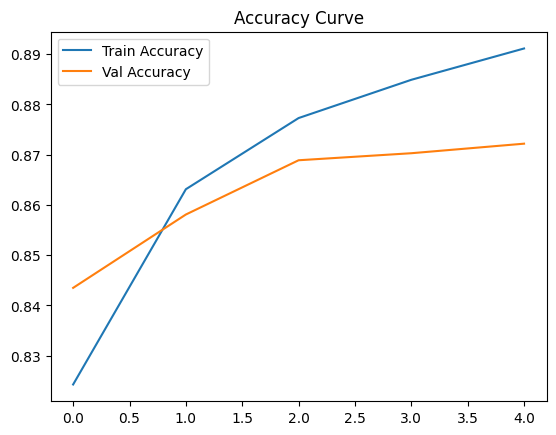

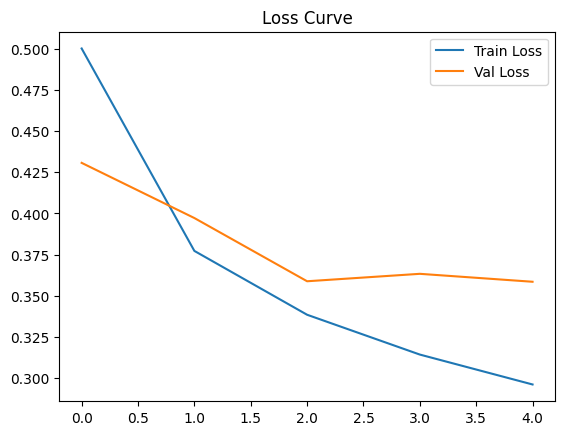

In [4]:
#9
import matplotlib.pyplot as plt
import tensorflow as tf

fashion = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

10: Fraud Detection Workflow (
1. Model Design
Use Multilayer Neural Network (MLP)
Input: transaction features
Hidden layers: 2–3 Dense layers
Output: Binary classification (fraud / not fraud)
2. Activation & Loss Function
Hidden layers: ReLU (fast, avoids vanishing gradient)
Output layer: Sigmoid (binary output)
Loss: Binary Crossentropy (best for classification)
3. Handling Imbalance
Use:
SMOTE (oversampling)
Class weights
F1-score evaluation instead of accuracy
4. Optimizer
Adam optimizer (fast + efficient convergence)
5. Prevent Overfitting
Dropout layers
Early stopping
L2 regularization

In [5]:
#10
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assume X, y dataset already loaded

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, class_weight={0:1, 1:5})

loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 1.5357
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 1.0000 - loss: 1.3878
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 1.4550
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 1.4186
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 1.4958
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 1.2947
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 1.0000 - loss: 1.2110
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 1.2765
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 1.3967
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 1.0000 - loss: 1.1762
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 1.0000 - loss: 0.3391
Accuracy: 1.0
